# Custom Figure Generator for Papers
- Load multiple runtime instances and compare plots.
- Assuming usage of similar spectral configuration (same specConfigName)
- 

In [4]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt
import pickle

# make plotPaths in top directory
topDir = os.path.dirname(os.getcwd())
plotDir = os.path.join(topDir, 'paperPlots')
if not os.path.exists(plotDir):
    os.makedirs(plotDir)
print("Saving plots to ", plotDir)

test = True
# test = False

Saving plots to  /Users/nguyendat/Documents/GitHub/polarVortexJwst/paperPlots


### Helpers function

In [5]:
### Functions to read in spectra time series data ###
default_specConfigName = '1200k_clouds=20'
def read_spec_codecs(photrunName, specConfigName=default_specConfigName):

    ### 1. Read in photometry results
    phot = readPhotometry(os.path.join(photometryh5dir, photrunName_ts))

    ### 2. Read in spectra time series data + codec data
    runname = f'timeseries_{photrunName[:-3]}_{specConfigName}'
    dirPath = os.path.join(os.getcwd(), runname)

    # Search for files matching the pattern 'i=*.h5' in the directory
    spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
    codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

    # Initialize the specs dictionary
    specs = {}
    codecs = {}

    # Iterate through each inclination file and load spectra
    for index, file in enumerate(spectra_files):
        inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename

        specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
        codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

    ### 3. Load codec configuration
    configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
    codec_loaded = CodecSystem()
    codec_loaded.import_mapping(configPath, validate_files=False)
    
    return phot, specs, codecs, codec_loaded

### Load in PICASO spectra: n=20 runs

- All photometry runs in this notebook should use the same PICASO spectra config n=20 (hence same fsed, wavelength region, cloud setup, etc. everything spectral related).

In [4]:

### Load the full picaso result summary

# Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
# specFolderName = 'bd_grid_20251108_162457_all5condensates'
# specFolderName = 'bd_grid_20251202_simple3clouds'
specFolderName = 'bd_grid_noCH4_20251209_153457'

specpath = os.path.join(dir, specFolderName)
specSummary = pickle.load(open(os.path.join(specpath, 'results_summary.pkl'), 'rb'))

modelID_list = [picasomodelfile['model_id'] for picasomodelfile in specSummary]
print(f"\nFound {len(modelID_list)} model IDs in the summary:")
print(modelID_list)
print("\nSample params file: ")
print(specSummary[0]['params'])

# fsed_list
fsed_list = []
# Loop through all codec_id and get fsed
for picasomodelfile in specSummary:
    fsed = picasomodelfile['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list.append((modelid, fsed))


Found 20 model IDs in the summary:
['bd_1200_10000_1.0E+07_1.00_cloudy', 'bd_1200_10000_1.0E+07_1.01_cloudy', 'bd_1200_10000_1.0E+07_1.02_cloudy', 'bd_1200_10000_1.0E+07_1.03_cloudy', 'bd_1200_10000_1.0E+07_1.04_cloudy', 'bd_1200_10000_1.0E+07_1.05_cloudy', 'bd_1200_10000_1.0E+07_1.06_cloudy', 'bd_1200_10000_1.0E+07_1.07_cloudy', 'bd_1200_10000_1.0E+07_1.08_cloudy', 'bd_1200_10000_1.0E+07_1.09_cloudy', 'bd_1200_10000_1.0E+07_1.10_cloudy', 'bd_1200_10000_1.0E+07_1.11_cloudy', 'bd_1200_10000_1.0E+07_1.12_cloudy', 'bd_1200_10000_1.0E+07_1.13_cloudy', 'bd_1200_10000_1.0E+07_1.14_cloudy', 'bd_1200_10000_1.0E+07_1.15_cloudy', 'bd_1200_10000_1.0E+07_1.16_cloudy', 'bd_1200_10000_1.0E+07_1.17_cloudy', 'bd_1200_10000_1.0E+07_1.18_cloudy', 'bd_1200_10000_1.0E+07_1.19_cloudy']

Sample params file: 
{'Teff': 1200, 'C_to_O': 0.0, 'mh': 1.0, 'gravity': 10000, 'kzz': 10000000.0, 'phase': 0, 'wave_range': [1, 6], 'eq': False, 'excluded_mol': 'CH4', 'mmw': 2.2, 'fsed': 1.0, 'R': 700, 'gases': ['Fe', 'M

### Read in photometry files for 

- type `ts`: Test Static (60hr baseline)
- type `td`: Test Dynamic (60hr baseline)
- type `js`: JWSR Static (180hr baseline)

In [ ]:

### Read the photometry file
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### Test-dataset: 

# 60 hours baseline, static pole: Test Static (ts)
photrunName_ts = 'test_polar_v0_static.h5'
phot_ts, specs_ts, codecs_ts, codec_loaded_ts = read_spec_codecs(photrunName_ts) 
time_ts = phot_ts['0']['time_array'] # load the time indices 

# 60 hours baseline, dynamic pole: Test Dynamic (td)
photrunName_td = 'test_polar_v0_dynamic.h5'
phot_td, specs_td, codecs_td, codec_loaded_td = read_spec_codecs(photrunName_td) 
time_td = phot_td['0']['time_array'] # load the time indices 

### JWST-data: 

# multiepoch, static pole: JWST Static (js)
photrunName_js = 'jwst_v0_static.h5'
phot_js, specs_js, codecs_js, codec_loaded_js = read_spec_codecs(photrunName_js)
time_js = phot_js['0']['time_array'] # load the time indices

Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_dynamic_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timese

In [ ]:
print(  phot_ts['90']['gray_array'].shape,
        phot_td['90']['gray_array'].shape,
        phot_js['90']['gray_array'].shape)
# temp fix: recreate time_js correctly by concatenating time_ts three times, with gap of 60 in between
time_js_corrected = np.concatenate([time_ts, time_ts + 60, time_ts + 120])
print("Corrected time_js shape: ", time_js_corrected.shape)


(120, 300, 300) (120, 300, 300) (120, 300, 300)
Corrected time_js shape:  (360,)


In [216]:
### Somes helpful metadata
# codec length
n = len(codec_loaded_ts.spectra_assignments.keys())

# how to load a spectrum
if test:
    wave, flux = codec_loaded_ts.load_spectrum(codec_id=0)
    print('### Spectral assignment keys ###: \n', codec_loaded_ts.spectra_assignments.keys())
    print('### Range of wavelength values ###: \n', wave[::50])
    print('### Corresponding flux ###: \n', flux[::50])


### Spectral assignment keys ###: 
 dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
### Range of wavelength values ###: 
 [0.99957438 1.07358431 1.15307404 1.23844931 1.33014588 1.42863181
 1.53440977 1.64801968 1.77004144 1.90109786 2.04185789 2.19304
 2.35541585 2.52981424 2.71712533 2.91830522 3.13438075 3.36645482
 3.615712   3.88342454 4.1709589  4.47978271 4.81147229 5.16772065
 5.55034615 5.96130179]
### Corresponding flux ###: 
 [2.45420234e-09 4.41506495e-09 6.82549022e-09 1.23148160e-08
 1.89032672e-08 1.73741067e-08 4.20557653e-08 5.93475747e-08
 7.22594861e-08 8.30731523e-08 1.26519555e-07 1.60537524e-07
 1.92009615e-07 1.51329476e-07 1.50701667e-07 2.40656328e-07
 3.19187019e-07 3.50685914e-07 3.76756954e-07 3.81990088e-07
 4.33680206e-07 4.61880014e-07 4.49066258e-07 4.46483576e-07
 2.70172383e-07 4.42915717e-07]


### [Figure] Spectral-codec image + all Picaso spectra | type `td`

{'0': 0.0031733268239449767, '1': 0.008026650201743176, '2': 0.0058584495211291875, '3': 0.005327168559654236, '4': 0.005700501127177175, '5': 0.006073833694700113, '6': 0.006662550435793978, '7': 0.006949729333888546, '8': 0.007524087130077682, '9': 0.008974340565455251, '10': 0.7153195583188547, '11': 0.12598538259408698, '12': 0.00852921327340867, '13': 0.008543572218313398, '14': 0.00871587955717014, '15': 0.009046135289978892, '16': 0.0119322832158293, '17': 0.01157330959321109, '18': 0.01283689674482719, '19': 0.02324713180075528}


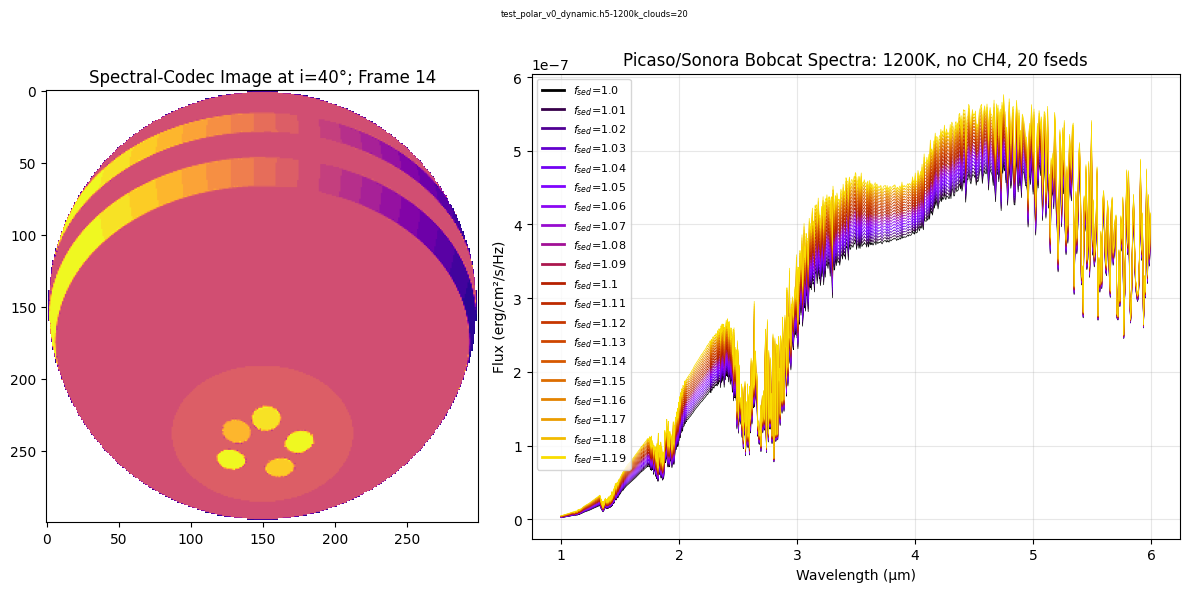

In [102]:
# ===== Plot all codecs spectra with an example image =====

# save = False
save = True

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1, 1.5])
codename = photrunName_td + '-' + default_specConfigName
if test: fig.suptitle(codename, fontsize=6)

ax = axes[0]
frame_id = 14
ax.imshow(codecs_td['40'][frame_id]['composite'], cmap='plasma')
ax.set_title(f'Spectral-Codec Image at i=40°; Frame {frame_id}')
print(codecs_td['40'][frame_id]['fractions']['fractions'])

# ===== Plot 1: All individual spectra =====
ax = axes[1]
for codec_id in range(n):  # Plot all codec
    wave_i, flux_i = codec_loaded_td.load_spectrum(codec_id)
    ax.plot(wave_i, flux_i, alpha=1, lw=0.5, color=plt.cm.gnuplot(codec_id / n))
    ax.plot([], [], lw=2, color=plt.cm.gnuplot(codec_id / n), 
            label=r'$f_{sed}$='+f'{fsed_list[codec_id][1]}')  # For legend

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Flux (erg/cm²/s/Hz)')
ax.set_title('Picaso/Sonora Bobcat Spectra: 1200K, no CH4, 20 fseds')
ax.legend(fontsize=8)
ax.set_yscale('linear')
ax.grid(True, alpha=0.3)

plt.tight_layout()
handle = f'all_codecs_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure]: Timeseries of atmo images at two inclination | type `td`

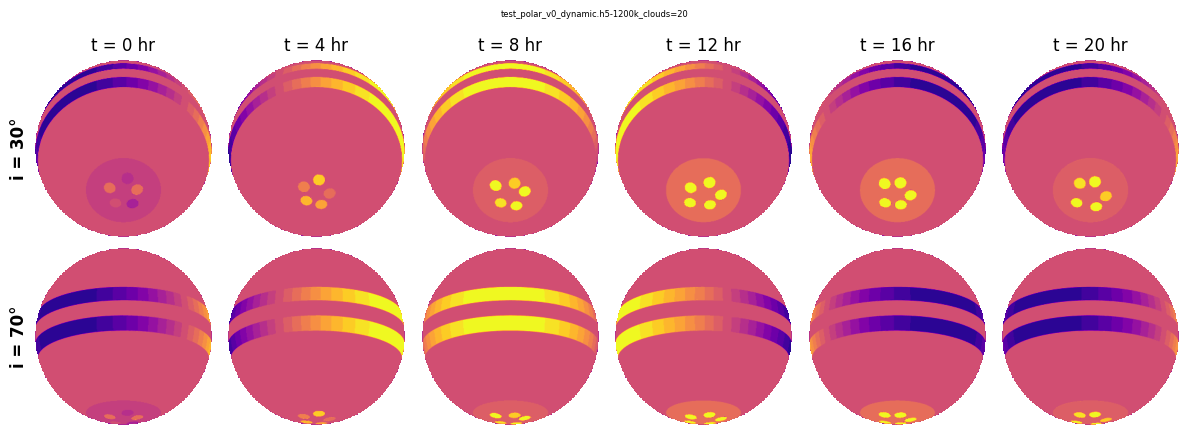

In [103]:
# Plot 2 rows of atmosphere image at two inclinations, each columns at different time
save = True
# save = False
codename = photrunName_td + '-' + default_specConfigName

fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))

if test: fig.suptitle(codename, fontsize=6)

time_indices = [i*8 for i in range(6)]  # select time indices
shift =[0, 0]

for i, inclin in enumerate(['30', '70']):
    for j, t_idx in enumerate(time_indices):
        t_idx += shift[i]
        ax = axes[i, j]
        ax.imshow(codecs_td[inclin][t_idx]['composite'], cmap='plasma')
        ax.set_xticks([])
        ax.set_yticks([])
        if i==0: ax.set_title(f't = {time_td[t_idx]:.0f} hr')
        if j==0: ax.set_ylabel(f'i = {inclin}°', fontsize=12, weight='bold')
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.tight_layout()
handle = f'atmo_images_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

#### Helpler function for wavebin flux calculation

In [10]:
# calculate binned flux at given wavelength range (take a spectra timeseries array per inclination)
def calculate_wavebin_flux(specs_inclin, wmin, wmax):
        flux_ts = []
        for keys in specs_inclin:
            frame_i, wave_i, flux_i = specs_inclin[keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_ts.append(median_flux)
        return flux_ts

### [Figure]: Lightcurves for 3 different wavelength bins for i = 10, 40, 80 | type `ts`

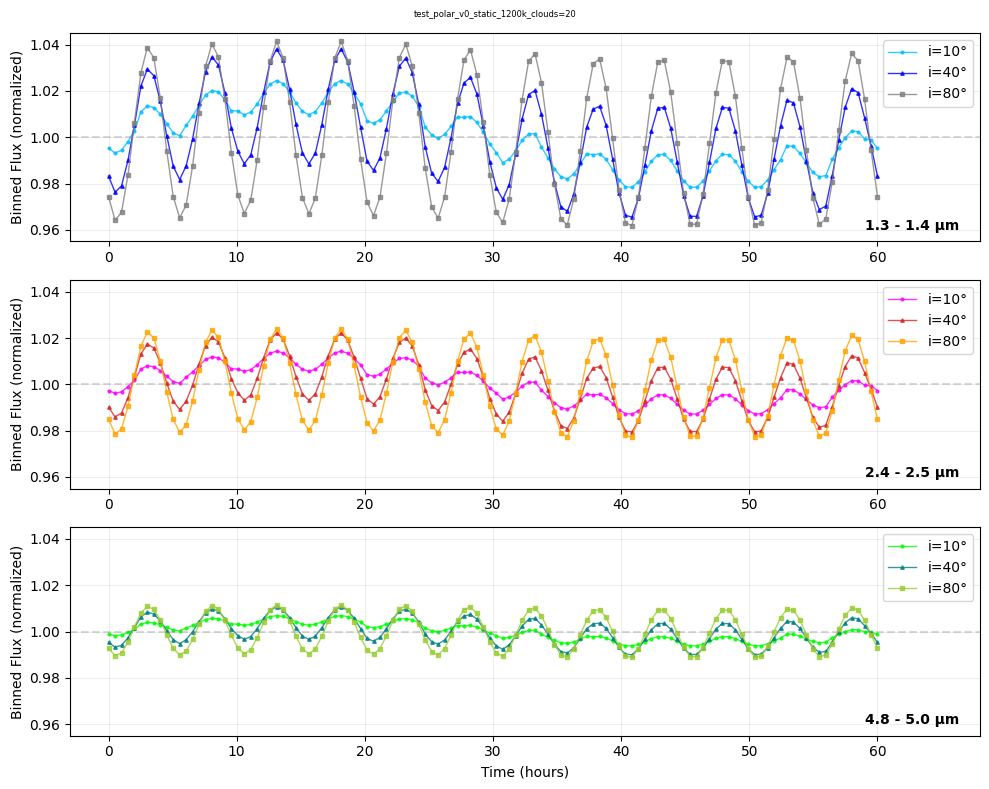

In [111]:
save = True
# save = False 
normalize = True
codename = photrunName_ts[:-3] + '_' + default_specConfigName

fig, axs = plt.subplots(3, 1, figsize=(10, 8))
if test: fig.suptitle(codename, fontsize=6)

wavebin = [ (1.3, 1.4),
            (2.4, 2.5),
            (4.8, 5.0) ]

inc_array = ['10', '40', '80']
markerstyles = ['o', '^', 's']
linestyles = ['-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = [['deepskyblue', 'blue', 'gray'],
            ['magenta', 'tab:red', 'orange'],
            ['lime', 'teal', 'yellowgreen']]

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs[i]
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
        
        # Plot normalized light curve
        # normalize flux mean to 1
        if normalize:
            flux_ts = np.array(flux_ts)
            flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1

        ax.plot(time_ts, flux_ts, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[i][j],
                linewidth=1, markersize=2+0.5*j,
                label=f'i={inclin}°')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(-3, 68)
    if normalize: ax.set_ylim(0.955, 1.045)
    ax.legend(),
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(59, 0.96, f'{wmin} - {wmax} μm', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


### [Figure]: Spectral ratio between two inclinations | type `ts`

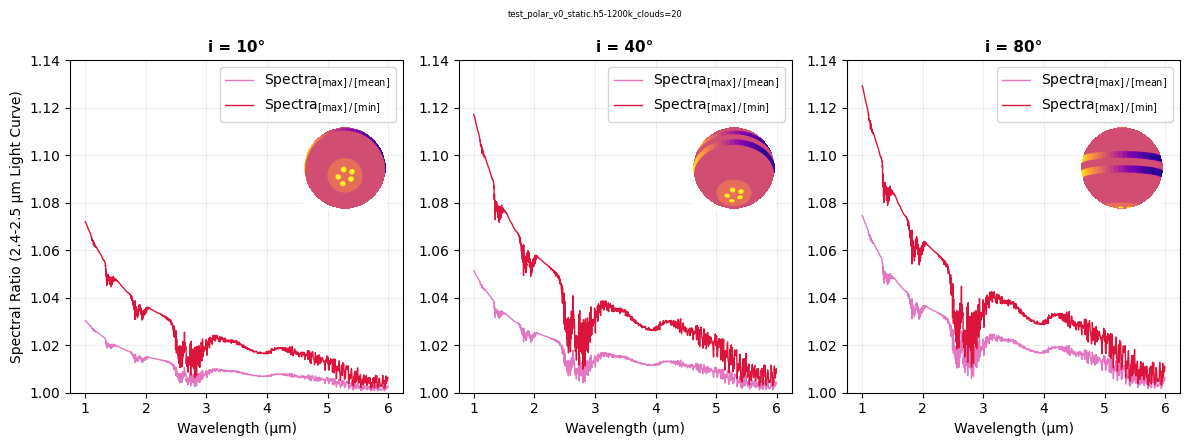

In [192]:
save = True
# save = False
normalize = True
codename = photrunName_ts[:-3] + '-' + default_specConfigName

fig, axs = plt.subplots(1, 3, figsize=(12, 4.5))
if test: fig.suptitle(photrunName_ts + '-' + default_specConfigName, fontsize=6)

# wmin, wmax = 1.3, 1.4
wmin, wmax = 2.4, 2.5
# wmin, wmax = 4.8, 5.0
inc_array = ['10', '40', '80']

for j, inclin in enumerate(inc_array):
    ax = axs[j]

    flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
    # find time id where flux is max, mid, min
    flux_ts = np.array(flux_ts)
    max_id = np.argmax(flux_ts)
    min_id = np.argmin(flux_ts)
    mid_id = (max_id + min_id) // 2
    
    framemax, wave, spectramax = specs_ts[inclin][max_id].values()
    framemid, _, spectramid = specs_ts[inclin][mid_id].values()
    framemin, _, spectramin = specs_ts[inclin][min_id].values()

    ax.plot(wave, spectramax/spectramid, lw=1, ls='-',
            label=r'Spectra$_\mathrm{ [max] \:/\: [mean]}$', c='tab:pink')
    ax.plot(wave, spectramax/spectramin, lw=1, ls='-',
            label=r'Spectra$_\mathrm{ [max] \:/\: [min]}$', c='crimson')

    # plot small inset of atmosphere image
    inset_ax = ax.inset_axes([0.7, 0.55, 0.25, 0.25])
    frame_id = 23
    inset_ax.imshow(codecs_ts[inclin][frame_id]['composite'], cmap='plasma')
    inset_ax.set_xticks([]), inset_ax.set_yticks([])
    # turn off the border
    for spine in inset_ax.spines.values():
        spine.set_visible(False)

    ax.set_xlabel('Wavelength (μm)', fontsize=10)
    if j==0: ax.set_ylabel(f'Spectral Ratio ({wmin}-{wmax} μm Light Curve)', fontsize=10)
    ax.set_title(f'i = {inclin}°', fontsize=11, weight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.set_ylim(1.0, 1.14)

plt.tight_layout()
handle = f'spectral_ratio_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

#### Calculate J-H, J-K colors and variab. amplitude through inclin. | type `ts`

In [168]:
### Calculate J-H, J-K colors and variability amplitudes at all inclinations

colorsJK, colorsJH = [], []
# get amplitudes at 2.4 and 2.8 microns
amplitudes1, amplitudes2, amplitudes3 = [], [], []

wavebin1 = (1.3, 1.4)
wavebin2 = (2.4, 2.5)
wavebin3 = (4.8, 5.0)

for inclin in specs_ts.keys():

    _, wave_i, flux_i = specs_ts[inclin][0].values()
    mean_flux = np.zeros_like(wave_i)

    # Define J, H, K band masks
    color_J_mask = (wave_i >= 1.1) & (wave_i <= 1.4)
    color_H_mask = (wave_i >= 1.5) & (wave_i <= 1.8)
    color_K_mask = (wave_i >= 2.2) & (wave_i <= 2.4)

    bin1_mask = (wave_i >= wavebin1[0]) & (wave_i <= wavebin1[1])
    bin2_mask = (wave_i >= wavebin2[0]) & (wave_i <= wavebin2[1])
    bin3_mask = (wave_i >= wavebin3[0]) & (wave_i <= wavebin3[1])

    # Get amplitude at each wavebins
    flux1, flux2, flux3 = [], [], []
    
    for keys in specs_ts[inclin]:
        _, wave_i, flux_i = specs_ts[inclin][keys].values()
        
        if np.sum(bin1_mask) > 0:
            # Calculate median flux in 2.4um and 2.8um bin
            flux1.append(np.median(flux_i[bin1_mask]))
            flux2.append(np.median(flux_i[bin2_mask]))
            flux3.append(np.median(flux_i[bin3_mask]))

        # Get mean flux for color calculation
        mean_flux += flux_i

    # Calculate 'color' value using mean flux within the J, H, K bands
    mean_flux /= len(specs_ts[inclin].keys())

    color_J_flux = np.mean(mean_flux[color_J_mask])
    color_H_flux = np.mean(mean_flux[color_H_mask])
    color_K_flux = np.mean(mean_flux[color_K_mask])

    colorJK = 2.5 * np.log10(color_J_flux / color_K_flux)
    colorJH = 2.5 * np.log10(color_J_flux / color_H_flux)

    colorsJK.append((float(inclin), colorJK))
    colorsJH.append((float(inclin), colorJH))

    # Calculate variability amplitude at each bins of wavelengths
    amplitudes1.append((float(inclin), 100*(np.max(flux1) - np.min(flux1)) / np.mean(flux1)))
    amplitudes2.append((float(inclin), 100*(np.max(flux2) - np.min(flux2)) / np.mean(flux2)))
    amplitudes3.append((float(inclin), 100*(np.max(flux3) - np.min(flux3)) / np.mean(flux3)))
    

### [Figure]: J-H, J-K colors and variab. amplitude through inclin. | type `ts`

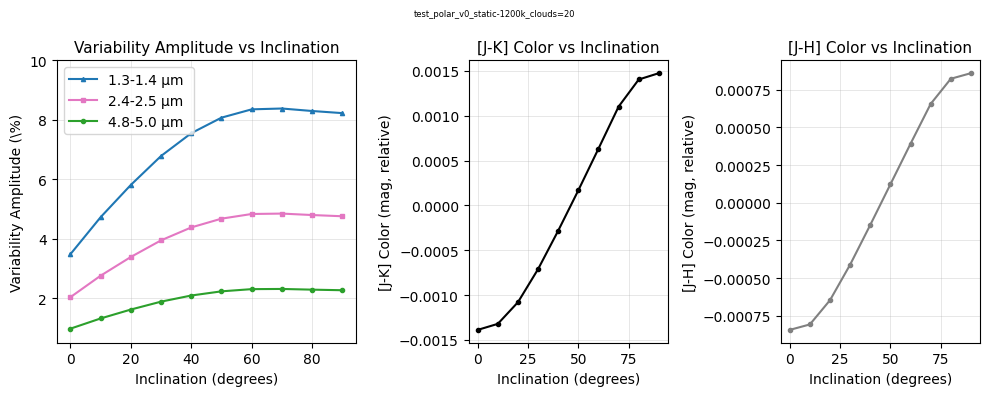

In [190]:
# ======= Relative J-K and J-H Color and variability amplitude vs Inclination Plot =======
save = True
# save = False

# Plot color vs inclination
fig, [ax3, ax1, ax2] = plt.subplots(1, 3, figsize=(10, 4), width_ratios=[1.5, 1, 1])

codename = photrunName_ts[:-3] + '-' + default_specConfigName
if test: fig.suptitle(codename, fontsize=6)

inclinations, JK_inc = zip(*colorsJK)
_, JH_inc = zip(*colorsJH)
_, amplitudes1_inc = zip(*amplitudes1)
_, amplitudes2_inc = zip(*amplitudes2)
_, amplitudes3_inc = zip(*amplitudes3)

JK_inc_mean, JH_inc_mean = np.mean(JK_inc), np.mean(JH_inc)
ax1.plot(inclinations, JK_inc - JK_inc_mean, marker='.', linestyle='-', 
         c='k')
ax1.set_title(f'[J-K] Color vs Inclination', fontsize=11)
ax1.set_xlabel('Inclination (degrees)')
ax1.set_ylabel('[J-K] Color (mag, relative)')
ax1.grid(True, alpha=0.3, lw=0.7)

ax2.plot(inclinations, JH_inc - JH_inc_mean, marker='.', linestyle='-',
        c='gray')
ax2.set_title(f'[J-H] Color vs Inclination', fontsize=11)
ax2.set_xlabel('Inclination (degrees)')
ax2.set_ylabel('[J-H] Color (mag, relative)')
ax2.grid(True, alpha=0.3, lw=0.7)

# Plot variability amplitude vs inclination
ax3.plot(inclinations, amplitudes1_inc, marker='^', markersize=3, linestyle='-', 
         c='tab:blue', label=f'{wavebin1[0]:.1f}-{wavebin1[1]:.1f} μm')
ax3.plot(inclinations, amplitudes2_inc, marker='s', markersize = 3, linestyle='-',
         c='tab:pink', label=f'{wavebin2[0]:.1f}-{wavebin2[1]:.1f} μm ')
ax3.plot(inclinations, amplitudes3_inc, marker='o', markersize=3, linestyle='-',
         c='tab:green', label=f'{wavebin3[0]:.1f}-{wavebin3[1]:.1f} μm ')
ax3.set_title(f'Variability Amplitude vs Inclination', fontsize=11)
ax3.set_xlabel('Inclination (degrees)')
ax3.set_ylabel('Variability Amplitude (\%)')
ax3.legend()
ax3.grid(True, alpha=0.3, lw=0.7)
ax3.set_ylim(0.5,10)

plt.tight_layout()
if save:
    handle = f'color_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure] Periodogram comparisons: different inclinations | type `ts`

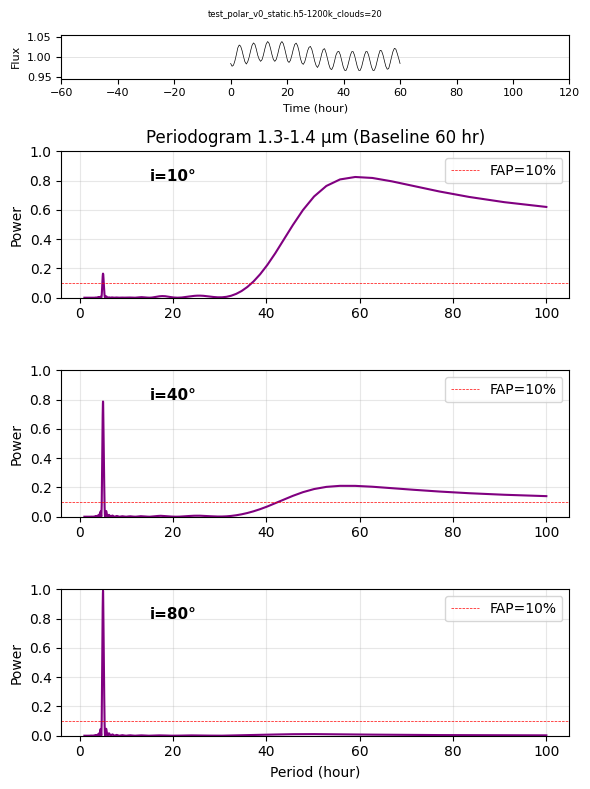

In [257]:
### Periodogram of lightcurve in hours 
from PyAstronomy.pyTiming import pyPeriod

save = True
# save = False
codename = photrunName_ts[:-3] + '-' + default_specConfigName

fig, axs = plt.subplots(4, 1 , figsize=(6, 8), height_ratios=[0.3, 1, 1, 1])
if test: fig.suptitle(photrunName_ts + '-' + default_specConfigName, fontsize=6)

wmin, wmax = 1.3, 1.4
inc_array = ['10', '40', '80']

# Light curve panel

ax0 = axs[0]
flux_ts = calculate_wavebin_flux(specs_ts['40'], wmin, wmax)
# normalize flux mean to 1
flux_ts = np.array(flux_ts)
flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1
ax0.plot(time_ts, flux_ts, color='k', lw=0.5)
ax0.set_xlabel('Time (hour)', fontsize=8)
ax0.set_ylabel('Flux', fontsize=8)
ax0.tick_params(labelsize=8)
ax0.set_ylim(0.945, 1.055)
ax0.set_xlim(-60, 120)

ax0.axhline(1, ls='-', color='gray', alpha=0.3, lw=0.5)

for i, inclin in enumerate(inc_array):
    ax = axs[i+1]

    freqs = np.linspace(0.01, 1, 1000) 

    flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
    flux_ts = np.array(flux_ts)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_ts, flux_ts, 0.001*flux_ts), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='purple')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={int(100*fap)}%')
    if i==2: ax.set_xlabel('Period (hour)')
    ax.set_ylabel('Power')
    if i==0: ax.set_title(f'Periodogram {wmin}-{wmax} μm (Baseline 60 hr)')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.text(15, 0.8, f'i={inclin}°', fontsize=11, weight='bold')

plt.tight_layout()
if save:
    handle = f'60hr_periodograms_vs_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure] Periodogram comparisons: different inclinations | type `js`

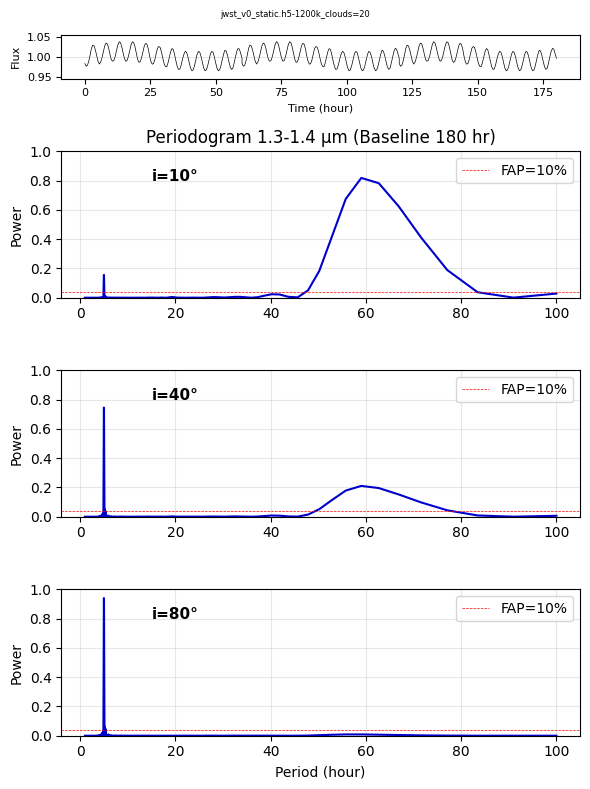

In [260]:
### Periodogram of lightcurve in hours of JWST static case
from PyAstronomy.pyTiming import pyPeriod

save = True
# save = False
codename = photrunName_js[:-3] + '-' + default_specConfigName

fig, axs = plt.subplots(4, 1 , figsize=(6, 8), height_ratios=[0.3, 1, 1, 1])
if test: fig.suptitle(photrunName_js + '-' + default_specConfigName, fontsize=6)

wmin, wmax = 1.3, 1.4
inc_array = ['10', '40', '80']

# Light curve panel

ax0 = axs[0]
flux_js = calculate_wavebin_flux(specs_js['40'], wmin, wmax)
# normalize flux mean to 1
flux_js = np.array(flux_js)
flux_js = (flux_js - np.mean(flux_js)) / np.max(flux_js) + 1
ax0.plot(time_js_corrected, flux_js, color='k', lw=0.5)
ax0.set_xlabel('Time (hour)', fontsize=8)
ax0.set_ylabel('Flux', fontsize=8)
ax0.tick_params(labelsize=8)
ax0.set_ylim(0.945, 1.055)
ax0.axhline(1, ls='-', color='gray', alpha=0.3, lw=0.5)

for i, inclin in enumerate(inc_array):
    ax = axs[i+1]

    freqs = np.linspace(0.01, 1, 1000) 

    flux_js = calculate_wavebin_flux(specs_js[inclin], wmin, wmax)
    flux_js = np.array(flux_js)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_js_corrected, flux_js, 0.001*flux_js), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='mediumblue')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={int(100*fap)}%')
    if i==2: ax.set_xlabel('Period (hour)')
    ax.set_ylabel('Power')
    if i==0: ax.set_title(f'Periodogram {wmin}-{wmax} μm (Baseline 180 hr)')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.text(15, 0.8, f'i={inclin}°', fontsize=11, weight='bold')

plt.tight_layout()
if save:
    handle = f'480hr_periodograms_vs_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### Figure: Vortices polar view + evolution path | all types

In [261]:
vortexPaths = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/default120_vortex_paths.pkl'
vortex_paths = pickle.load(open(vortexPaths, 'rb'))


Polar view:
  r_inner (lat 90°) = 7.50
  r_outer (lat 65°) = 15.00


/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_47369/1121714214.py:45: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, y, '-', color=colors[i], alpha=0.8,


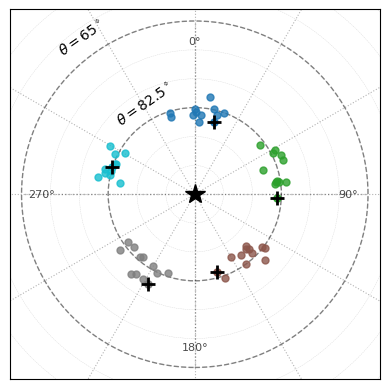

In [347]:
verbose = False
# Set up band_config: latitudinal features
Ppol, Pband, Prot = 60, 5, 5  # Periods in hours
Fpolar, Fband, Fambient = 0.98, 1, 1 # amp
Fpolar_var, Fband_var, Fambient_var = 0.05, 0.15, 0.00 # variab

lat2, lat1, amp, typ, phase, period, planet_period, variab = [90, 65, Fpolar, 'P', 0, Ppol, Prot, Fpolar_var]
center_lat = 82.5

if lat1 < lat2:
    lat1, lat2 = lat2, lat1

# ======= Plot vortex paths in polar view =======
fig, ax = plt.subplots(figsize=(4,4))
ax.set_aspect('equal')
colors = plt.cm.tab10(np.linspace(0, 1, 5))

# Polar cap boundaries
r_inner = 90 - center_lat
r_outer = 15

print(f"\nPolar view:")
print(f"  r_inner (lat {lat1}°) = {r_inner:.2f}")
print(f"  r_outer (lat {lat2}°) = {r_outer:.2f}")

for i in range(5):
    lons = np.array(vortex_paths[i]['lons'])
    lats = np.array(vortex_paths[i]['lats'])
    
    # Convert to polar coordinates
    r = 90 - lats
    theta = np.radians(lons)
    
    # Convert to Cartesian
    x = r * np.sin(theta)
    y = r * np.cos(theta)
    
    if verbose:
        print(f"\nVortex {i} in polar coords:")
        print(f"  r: min={r.min():.2f}, max={r.max():.2f}")
        print(f"  x: min={x.min():.2f}, max={x.max():.2f}")
        print(f"  y: min={y.min():.2f}, max={y.max():.2f}")
    
    # Plot vortex centroids evolution
    ax.plot(x, y, '-', color=colors[i], alpha=0.8, 
            ls='', marker='o', markersize=5,
            label=f'Vortex {i+1}', zorder=5)
    
    # Markers of centroid start positions
    ax.plot(x[0], y[0], '+', color=colors[i], markersize=10, alpha=1,
            markeredgecolor='black', markeredgewidth=2, zorder=10)
    
# Draw circles
from matplotlib.patches import Circle
circle_inner = Circle((0, 0), r_inner, fill=False, edgecolor='gray',
                    ls='--', linewidth=1)
circle_outer = Circle((0, 0), r_outer, fill=False, edgecolor='gray',
                    ls='--', linewidth=1)
ax.add_patch(circle_inner)
ax.add_patch(circle_outer)

# Pole
ax.plot(0, 0, 'k*', markersize=15, zorder=15)

# Longitude lines
for lon in [0, 90, 180, 270]:
    theta_rad = np.radians(lon)
    x_line = r_outer * np.sin(theta_rad)
    y_line = r_outer * np.cos(theta_rad)
    ax.plot([0, x_line], [0, y_line], 'k:', alpha=0.3, linewidth=1)
    
    label_r = r_outer - 1.75
    ax.text(label_r * np.sin(theta_rad), label_r * np.cos(theta_rad), 
            f'{lon}°', ha='center', va='center', fontsize=8, alpha=0.7)

ax.text(-7, 6, r'$\theta=82.5^\circ$', fontsize=10, rotation=35)
ax.text(-12, 12, r'$\theta=65^\circ$', fontsize=10, rotation=35)

padding = 1
ax.set_xlim(-r_outer-padding, r_outer+padding)
ax.set_ylim(-r_outer-padding, r_outer+padding)
ax.set_xticks([]), ax.set_yticks([])
# ax.set_xlabel('East ←→ West', fontsize=12)
# ax.set_ylabel('South ←→ North', fontsize=12)

# Draw polar coordinate grid (circles)
for r_grid in np.arange(0, r_outer + 10, 2.5):
    circle = Circle((0, 0), r_grid, fill=False, edgecolor='gray', linestyle='--', linewidth=0.3, alpha=0.3)
    ax.add_patch(circle)

# Add radial lines for polar grid
for lon in np.arange(0, 360, 30):
    theta_rad = np.radians(lon)
    x_line = 2* r_outer * np.sin(theta_rad)
    y_line = 2* r_outer * np.cos(theta_rad)
    ax.plot([0, x_line], [0, y_line], 'k:', alpha=0.3, linewidth=0.8)

plt.tight_layout()

### Figure: Plot flux-value non-codecized for only-vortex scenarios | type `vs, vd1, vd2` 
- time config: 0-180 hours, 120 frames
- vd1 have different phase offset values from vd2

In [ ]:
# Load your data
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### test onlyVortex static/dynamic
photrunName = 'test_onlyVortex_v0_static.h5'
phot_vs = readPhotometry(os.path.join(photometryh5dir, photrunName))

photrunName = 'test_onlyVortex_v0_dynamic1.h5'
phot_vd1 = readPhotometry(os.path.join(photometryh5dir, photrunName))

photrunName = 'test_onlyVortex_v0_dynamic2.h5'
phot_vd2 = readPhotometry(os.path.join(photometryh5dir, photrunName))

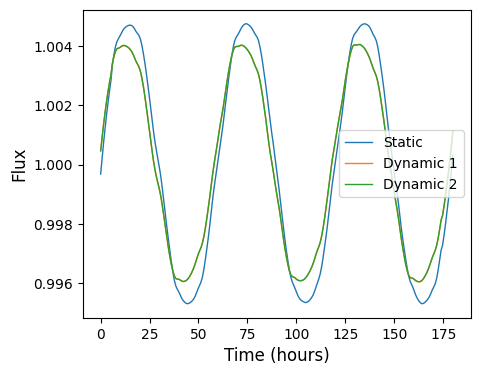

In [25]:

flux_vs, flux_vd1, flux_vd2 = [], [], []
inclin = '0'  # polar view
time = phot_vs[inclin]['time_array']

for i in range(len(time)):
    flux_vs.append(np.sum(phot_vs[inclin]['gray_array'][i]))
    flux_vd1.append(np.sum(phot_vd1[inclin]['gray_array'][i]))
    flux_vd2.append(np.sum(phot_vd2[inclin]['gray_array'][i]))

# normalize flux
flux_vs = np.array(flux_vs)
flux_vd1 = np.array(flux_vd1)
flux_vd2 = np.array(flux_vd2)

flux_vs = (flux_vs - np.mean(flux_vs)) / np.max(flux_vs) + 1
flux_vd1 = (flux_vd1 - np.mean(flux_vd1)) / np.max(flux_vd1) + 1
flux_vd2 = (flux_vd2 - np.mean(flux_vd2)) / np.max(flux_vd2) + 1

# interpolate to double time resolution
from scipy.interpolate import interp1d
interp_func_vs = interp1d(time, flux_vs, kind='cubic')
interp_func_vd1 = interp1d(time, flux_vd1, kind='cubic')
interp_func_vd2 = interp1d(time, flux_vd2, kind='cubic')
time_new = np.linspace(time[0], time[-1], num=2*len(time))
flux_vs = interp_func_vs(time_new)
flux_vd1 = interp_func_vd1(time_new)
flux_vd2 = interp_func_vd2(time_new)

# smooth flux with a scipy.signal function
from scipy.signal import savgol_filter
window, poly = 16, 2
flux_vs = savgol_filter(flux_vs, window, poly)
flux_vd1 = savgol_filter(flux_vd1, window, poly)
flux_vd2 = savgol_filter(flux_vd2, window, poly)

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(time_new, flux_vs, label='Static', lw=1)
ax.plot(time_new, flux_vd1, label='Dynamic 1', lw=1)
ax.plot(time_new, flux_vd2, label='Dynamic 2', lw=1)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Flux', fontsize=12)
ax.legend()
plt.show()
plt.close()
